In [1]:
import numpy as np
import os
import pytoml
import matplotlib.pyplot as plt

import sys
sys.path.append("../")

from spore.physics import Neutrino, InteractionType
from spore.conventions import units, Event
from spore.source import source_from_config
from spore.detector import detector_from_config
from spore.fun.sample_event import sample_events

ImportError: cannot import name 'source_from_config' from 'spore.source' (/Users/jlazar/research/spore/spore/source/__init__.py)

In [2]:
with open("../resources/configs/powerlaw_source_example.toml") as f:
    source_config = pytoml.load(f)
    source1 = source_from_config(source_config)
    
    source_config["location"]["right_ascension"] = 200
    source_config["location"]["declination"] = 0
    source_config["flux"]["energy"]["gamma"] = 1
    source2 = source_from_config(source_config)
    
with open("../resources/configs/example_detector.toml") as f:
    detector_config = pytoml.load(f)
    detector_config["response"]["detector_response_file"] = os.path.abspath("../" + detector_config["response"]["detector_response_file"])
    detector = detector_from_config(detector_config)

In [3]:
events1 = sample_events(detector, source1, 365*units.day)
events2 = sample_events(detector, source2, 365*units.day)

In [7]:
event = events1[0]

In [17]:
from spore.conventions.utils import sky_to_local

In [21]:
sky_to_local(event.true_direction, detector.location, 60612.5)

LocalCoordinate(zenith=np.float64(1.659669985997722), azimuth=np.float64(3.3514074484146175))

In [4]:
def is_track(event: Event) -> bool:
    if event.interaction!=InteractionType.ChargedCurrent:
        return False
    if event.initial_neutrino not in [Neutrino.NuMu, Neutrino.NuMuBar]:
        return False
    return True

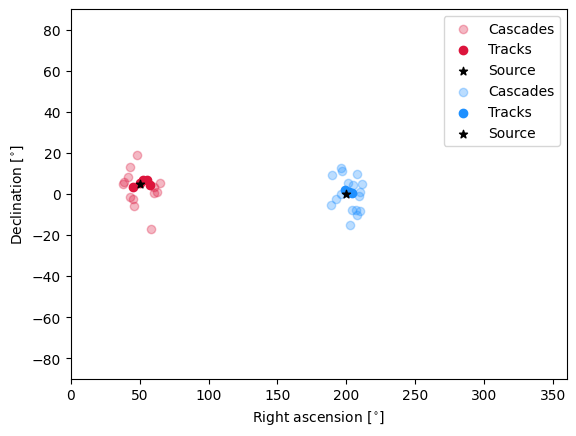

In [5]:
colors = ["crimson", "dodgerblue"]
for source, events, color in zip([source1, source2], [events1, events2], colors):
    decs, ras, is_tracks = [], [], []
    for event in events:
        decs = np.append(decs, event.reco_direction.declination)
        ras = np.append(ras, event.reco_direction.right_ascension)
        is_tracks = np.append(is_tracks, is_track(event)).astype(bool)

    plt.scatter(
        np.degrees(ras[~is_tracks]),
        np.degrees(decs[~is_tracks]),
        c=color,
        label="Cascades",
        alpha=0.3
    )
    plt.scatter(
        np.degrees(ras[is_tracks]),
        np.degrees(decs[is_tracks]),
        c=color,
        label="Tracks",
    )
    plt.scatter(
        np.degrees([source.location.right_ascension]),
        np.degrees([source.location.declination]),
        c="k",
        label="Source",
        marker="*"
    )
 
plt.xlim(0, 360)
plt.ylim(-90, 90)

plt.xlabel(r"Right ascension$~\left[^{\circ}\right]$")
plt.ylabel(r"Declination$~\left[^{\circ}\right]$")

plt.legend()

plt.show()

In [6]:
q = [np.arccos(np.sum(event.true_direction.to_cartesian() * event.reco_direction.to_cartesian())) for event in events1]
p = [np.arccos(np.sum(event.true_direction.to_cartesian() * event.reco_direction.to_cartesian())) for event in events2]


In [7]:
print(np.quantile(p, [0.1, 0.5, 0.9]))
print(np.quantile(q, [0.1, 0.5, 0.9]))


[0.03502551 0.15844423 0.25892186]
[0.04504911 0.19514214 0.30691224]


In [8]:
m = map(lambda x: x.true_energy, events1)

In [22]:
from tqdm import tqdm

In [28]:
nrun = 1000
ctr = np.zeros((nrun, 2))

for idx in tqdm(range(nrun)):
    events = sample_events(detector, source1, 36.5*units.day)
    ntrack, ncascade = 0, 0
    for event in events:
        if is_track(event):
            ntrack += 1
        else:
            ncascade += 1
        ctr[idx, :] = [ntrack, ncascade]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:32<00:00, 31.01it/s]


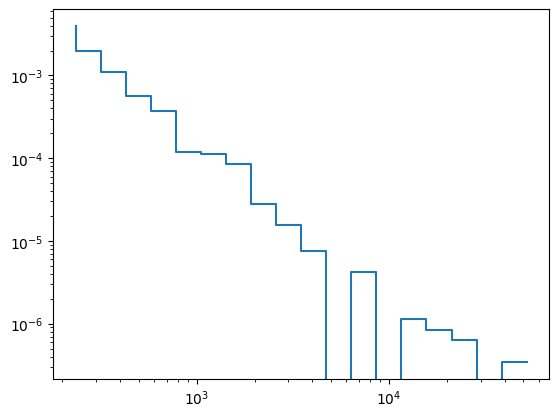

In [39]:
events = sample_events(detector, source1, 3650*units.day)
energies = np.array([event.true_energy for event in events])
bins = np.logspace(
    np.log10(energies.min()),
    np.log10(energies.max()),
    20
)
cents = (bins[1:] + bins[:-1]) /2
widths = (bins[1:] - bins[:-1])

h, _ = np.histogram(energies, bins=bins)

plt.step(cents / units.GeV, h / h.sum() / (widths / units.GeV))
plt.loglog()
plt.show()

In [30]:
effa = list(detector.response.effective_area.values())[0]

In [31]:
effa(0, 1e6 * units.GeV) / units.meter**2

np.float64(585.2669775005608)

In [20]:
from scipy.interpolate import interp1d

In [23]:
data = np.genfromtxt("/Users/jlazar/Downloads/cc_xs.csv", delimiter=",")

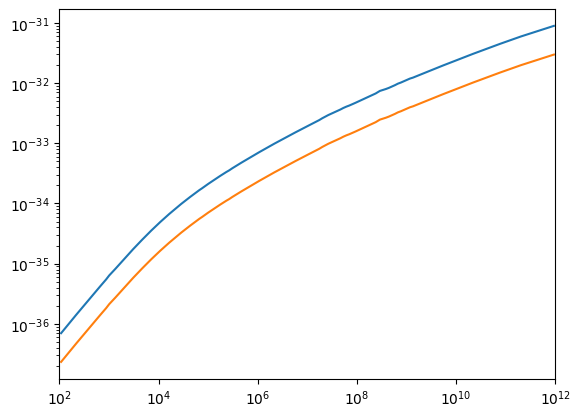

In [61]:
es = data[:, 0] * units.GeV
xss = data[:, 1] * units.cm**2

int_cc = interp1d(np.log(es), np.log(xss))
int_nc = interp1d(np.log(es), np.log(xss / 3))
sigma_cc = lambda e: np.exp(int_cc(np.log(e)))
sigma_nc = lambda e: np.exp(int_nc(np.log(e)))

plt.plot(es / units.GeV, sigma_cc(es) / units.cm**2)
plt.plot(es / units.GeV, sigma_nc(es) / units.cm**2)
plt.loglog()
plt.xlim(1e2, 1e12)
plt.show()

In [72]:
mproton = 0.938 * units.GeV
vdetector = (1 * units.km)**3
density_ice = 0.92 * units.gr / units.cm**3

ntarget = density_ice / mproton * vdetector
f = lambda e: effa(0, e) / (3 * ntarget * sigma_cc(e))

In [73]:
sigma_cc(1e4*units.GeV) / units.cm**2

np.float64(4.636060781901758e-35)

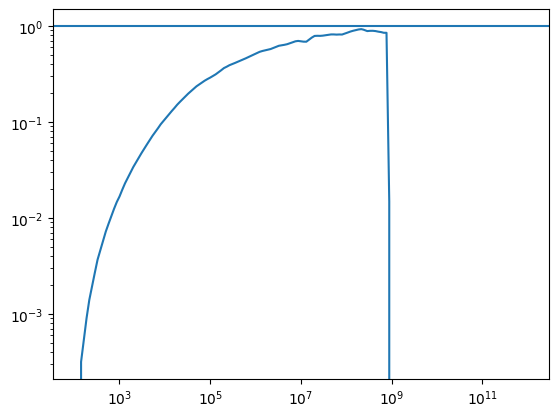

In [82]:
plt.plot(es / units.GeV, [f(e) / 10 for e in es])
plt.axhline(1)
# plt.plot(es / units.GeV, [sigma_cc(e) * (effa(0, 1000*units.GeV) / sigma_cc(1000*units.GeV)) for e in es])
plt.loglog()
plt.show()